# Reinforcement Learning

### Intelligentes Laden eines Elektrotaxis mithilfe von bestärkendem Lernen

Bei dieser Aufgabe implementieren wir einen Ansatz des Reinforcement Learnings für das intelligente Laden eines Elektrotaxis. 
Wir nehmen an, dass das Taxi jeden Tag um 14:00 Uhr in der Garage ist und um 16.00 Uhr wieder los fährt. Während dieser Zeit entscheidet der intelligente Ladeagent alle 15 Minuten, wie viel ladeleistung zugeführt werden soll.

Ziele:
- Minimierung der Ladekosten
- Sicherstellung, dass die Batterie genügend Energie für den Arbeitstag enthält
- Batteriemagel zu vermeiden, der zu einer hohen Strafgebühr führt

Der erste Ansatz ist ein Deep Q-Network (DQN), umm die optimale Ladestrategie zu erlernen.

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym #for creating the reinforcement learning environment
from gymnasium import spaces

from stable_baselines3 import DQN #for training the DQN agent
from stable_baselines3.common.env_checker import check_env

### Environment

Um einen Agenten für das Reinforcement Lernen zu trainieren, muss der Ladevorgang als Environment dargestellt werden. 
Die Umgebung umfasst:

- Batteriekapazität
- Aktueller Ladezustand (SOC)
- Verfügbare Ladeaktionen
- Ladekosten
- Stochastischer täglicher Energiebedarf

Der Agent sollte mit dieser Umgebung interagieren und auf Grundlage seiner Entscheidungen belohnt oder bestraft werden


In [2]:
class TaxiChargingEnv(gym.Env):

    def __init__(self):

        super().__init__()

        # Maximum battery capacity in kWh
        self.capacity = 50.0

        # Initial battery level when arriving home
        self.initial_soc = 20.0

        # Number of charging decisions
        # (2 hours / 15 minutes = 8 intervals)
        self.max_steps = 8

        self.current_step = 0

        # Discrete charging actions
        self.power_levels = [0, 5, 11, 22]

        self.action_space = spaces.Discrete(len(self.power_levels))

        # ---- State ----

        self.observation_space = spaces.Box(
            low=np.array([0,0]),
            high=np.array([50,8]),
            dtype=np.float32
        )

    def reset(self, seed=None, options=None): #initialize a new charging epiode

        super().reset(seed=seed)

        self.current_step = 0

        self.soc = self.initial_soc

        obs = np.array(
            [self.soc, self.current_step],
            dtype=np.float32
        )

        return obs, {}

    def step(self, action):

        power = self.power_levels[action]

        # 15 minutes = 0.25 h

        energy_added = power * 0.25

        self.soc = min(
            self.capacity,
            self.soc + energy_added
        )

        alpha = 0.01

        charging_cost = alpha * np.exp(power / 5)

        reward = -charging_cost

        self.current_step += 1

        terminated = False

        if self.current_step >= self.max_steps:

            demand = np.random.normal(
                loc=30,
                scale=5
            )

            if self.soc < demand:

                reward -= 1000

            else:

                reward += 100

            terminated = True

        obs = np.array(
            [self.soc, self.current_step],
            dtype=np.float32
        )

        return obs, reward, terminated, False, {}

In [3]:
env = TaxiChargingEnv()

check_env(env) #check check

print("Environment valid.")

Environment valid.


### Deep-Q-Network-Agent

Das DQN schätzt die erwartete zukünftige Belohnung für jede Ladeaktion und verbessert seine Entscheidungen schrittweise durch Interaktion mit der Umgebung.

In [4]:
env = TaxiChargingEnv()

model = DQN(
    "MlpPolicy",
    env,
    learning_rate=0.001,
    buffer_size=10000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    verbose=1
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [5]:
model.learn(
    total_timesteps=50000
)


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 8        |
|    ep_rew_mean      | 98       |
|    exploration_rate | 0.994    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 15281    |
|    time_elapsed     | 0        |
|    total_timesteps  | 32       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 8        |
|    ep_rew_mean      | 98.2     |
|    exploration_rate | 0.988    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 17797    |
|    time_elapsed     | 0        |
|    total_timesteps  | 64       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 8        |
|    ep_rew_mean      | 6.62     |
|    exploration_rate | 0.982    |
| time/               |          |
|    episodes       

In [6]:
model.save("taxi_charging_dqn")

In [7]:
env = TaxiChargingEnv()

obs, _ = env.reset()

done = False

total_reward = 0

while not done:

    action, _ = model.predict(
        obs,
        deterministic=True
    )

    obs, reward, done, _, _ = env.step(action)

    total_reward += reward

print("Reward:", total_reward)

Reward: -1000.3722988598367


In [8]:
n_episodes = 1000

success = 0
rewards = []

for _ in range(n_episodes):

    obs, _ = env.reset()

    done = False
    total_reward = 0

    while not done:

        action, _ = model.predict(
            obs,
            deterministic=True
        )

        obs, reward, done, _, _ = env.step(action)

        total_reward += reward

    rewards.append(total_reward)

    if total_reward > 0:
        success += 1

print(f"Success rate: {success/n_episodes*100:.2f}%")
print(f"Average reward: {np.mean(rewards):.2f}")
print(f"Minimum reward: {np.min(rewards):.2f}")
print(f"Maximum reward: {np.max(rewards):.2f}")

Success rate: 64.20%
Average reward: -294.17
Minimum reward: -1000.37
Maximum reward: 99.63


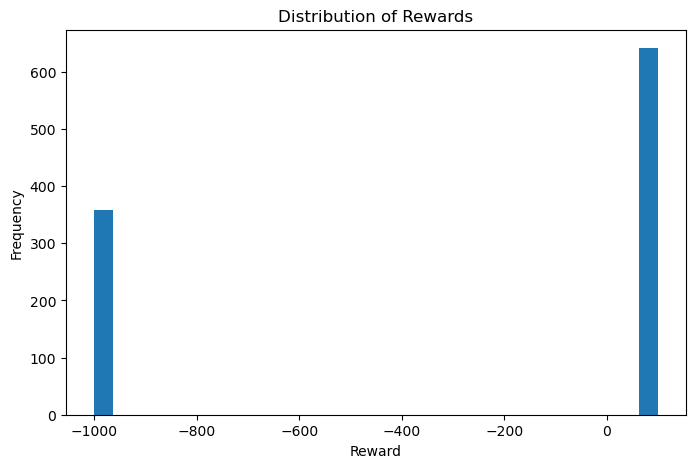

In [9]:
plt.figure(figsize=(8,5))

plt.hist(rewards, bins=30)

plt.title("Distribution of Rewards")
plt.xlabel("Reward")
plt.ylabel("Frequency")

plt.show()

In [10]:
action_counts = np.zeros(4)

obs, _ = env.reset()

done = False

while not done:

    action, _ = model.predict(
        obs,
        deterministic=True
    )

    action_counts[action] += 1

    obs, reward, done, _, _ = env.step(action)

print(action_counts)

[2. 3. 3. 0.]


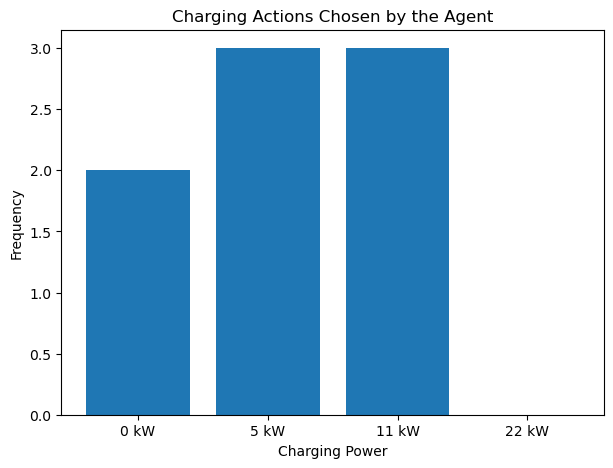

In [11]:
labels = [
    "0 kW",
    "5 kW",
    "11 kW",
    "22 kW"
]

plt.figure(figsize=(7,5))

plt.bar(labels, action_counts)

plt.title("Charging Actions Chosen by the Agent")
plt.xlabel("Charging Power")
plt.ylabel("Frequency")

plt.show()

In [12]:
obs, _ = env.reset()

done = False

step = 0

print("Step | Battery | Action")

while not done:

    action, _ = model.predict(
        obs,
        deterministic=True
    )

    print(
        f"{step:>4} | "
        f"{obs[0]:>7.2f} kWh | "
        f"{env.power_levels[action]} kW"
    )

    obs, reward, done, _, _ = env.step(action)

    step += 1

print("\nFinal reward:", reward)

Step | Battery | Action
   0 |   20.00 kWh | 11 kW
   1 |   22.75 kWh | 11 kW
   2 |   25.50 kWh | 11 kW
   3 |   28.25 kWh | 0 kW
   4 |   28.25 kWh | 0 kW
   5 |   28.25 kWh | 5 kW
   6 |   29.50 kWh | 5 kW
   7 |   30.75 kWh | 5 kW

Final reward: -1000.0271828182846
